# QBL Primary Pairing Recurrence — claim notebook

No file I/O. Each code cell tests one bounded claim and emits one figure.

PASS: c_A=T_A-2T_{A-1} is recoverable for A>=1
T= [9, 27, 61, 130, 269, 545, 1098, 2205, 4417, 8842]
c= [9, 7, 8, 9, 7, 8, 9, 7, 8]


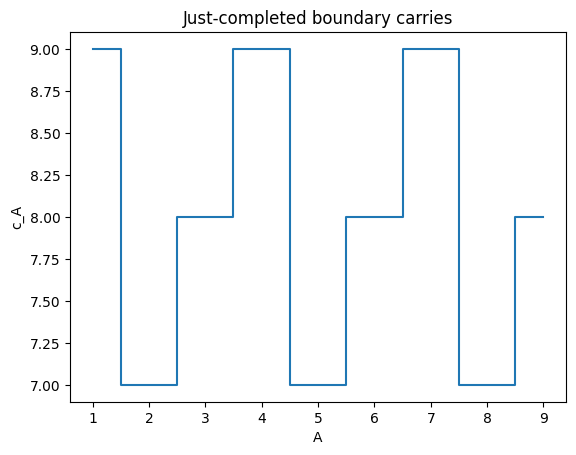

In [1]:
from math import ceil, log, sqrt
import matplotlib.pyplot as plt
phi=(1+sqrt(5))/2
def T(A): return ceil((12*(2**(A+1)-1)*log(2)+log(5))/(2*log(phi))-1.5)
Ts=[T(A) for A in range(10)]
cs=[Ts[A]-2*Ts[A-1] for A in range(1,10)]
ok=all(c in (7,8,9) for c in cs)
print(('PASS' if ok else 'FAIL')+': c_A=T_A-2T_{A-1} is recoverable for A>=1')
print('T=',Ts)
print('c=',cs)
fig,ax=plt.subplots();ax.step(range(1,10),cs,where='mid');ax.set(xlabel='A',ylabel='c_A',title='Just-completed boundary carries');plt.show()

PASS: instantaneous L carries current data but does not supply future c_1
S_0^- = {'A': 0, 'B_count': 9, 'q': (55, 89)}
S_0^+ = {'A': 1, 'B_count': 9, 'q': (55, 89)}
missing= T_1 after complete next-domain return


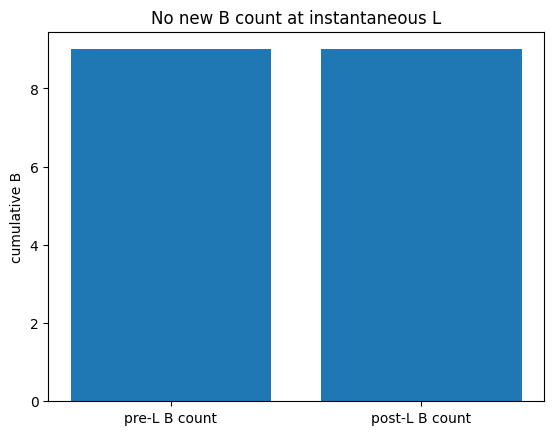

In [2]:
import matplotlib.pyplot as plt
pre={'A':0,'B_count':9,'q':(55,89)}
post={'A':1,'B_count':9,'q':(55,89)}
future_required='T_1 after complete next-domain return'
ok=(pre['B_count']==post['B_count'] and pre['q']==post['q'])
print(('PASS' if ok else 'FAIL')+': instantaneous L carries current data but does not supply future c_1')
print('S_0^- =',pre);print('S_0^+ =',post);print('missing=',future_required)
fig,ax=plt.subplots();ax.bar(['pre-L B count','post-L B count'],[pre['B_count'],post['B_count']]);ax.set(title='No new B count at instantaneous L',ylabel='cumulative B');plt.show()

PASS: minimal duality-morphism interface supports all four derived blocks
interface= P_t : H_t -> D(H_t)
{'one primary source': 1, 'two restrictions by pullback': 1, 'two mixed blocks by pullback': 1, 'finite biproduct at L': 1}


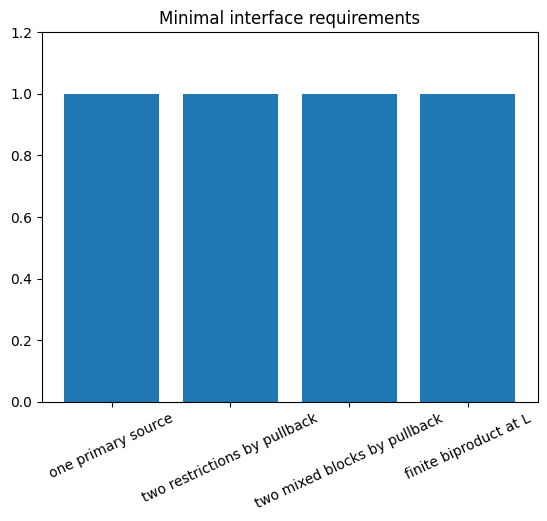

In [3]:
import matplotlib.pyplot as plt
requirements={'one primary source':1,'two restrictions by pullback':1,'two mixed blocks by pullback':1,'finite biproduct at L':1}
minimal='P_t : H_t -> D(H_t)'
ok=all(requirements.values())
print(('PASS' if ok else 'FAIL')+': minimal duality-morphism interface supports all four derived blocks')
print('interface=',minimal);print(requirements)
fig,ax=plt.subplots();ax.bar(list(requirements),list(requirements.values()));ax.set_ylim(0,1.2);ax.tick_params(axis='x',rotation=25);ax.set(title='Minimal interface requirements');plt.show()

PASS: ordinary and conjugate scalar variance share the seed witness but differ elsewhere
at (1,1): 1 1 ; at (i,1): I -I


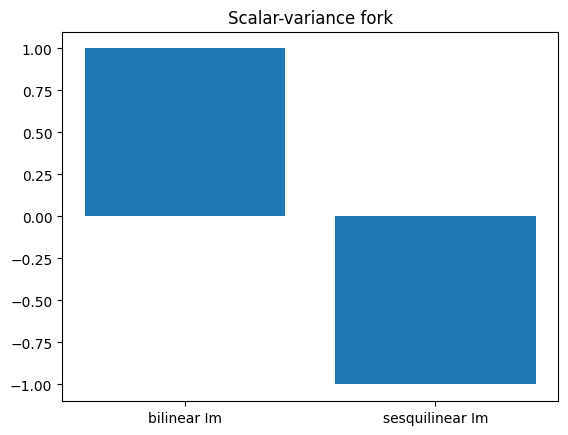

In [4]:
import sympy as sp
import matplotlib.pyplot as plt
x=sp.I;y=sp.Integer(1)
bil=x*y
sesq=sp.conjugate(x)*y
seed_bil=sp.Integer(1)*sp.Integer(1)
seed_sesq=sp.conjugate(sp.Integer(1))*sp.Integer(1)
ok=(seed_bil==seed_sesq==1 and sp.simplify(bil-sesq)!=0)
print(('PASS' if ok else 'FAIL')+': ordinary and conjugate scalar variance share the seed witness but differ elsewhere')
print('at (1,1):',seed_bil,seed_sesq,'; at (i,1):',bil,sesq)
fig,ax=plt.subplots();ax.bar(['bilinear Im','sesquilinear Im'],[float(sp.im(bil)),float(sp.im(sesq))]);ax.set(title='Scalar-variance fork');plt.show()

PASS: seed is not unique at raw presentation level under current authority
{'coefficient ring': 1, 'duality variance': 1, 'symmetry law': 1, 'seed gauge presentation': 1, 'normalization beyond local witness': 1}


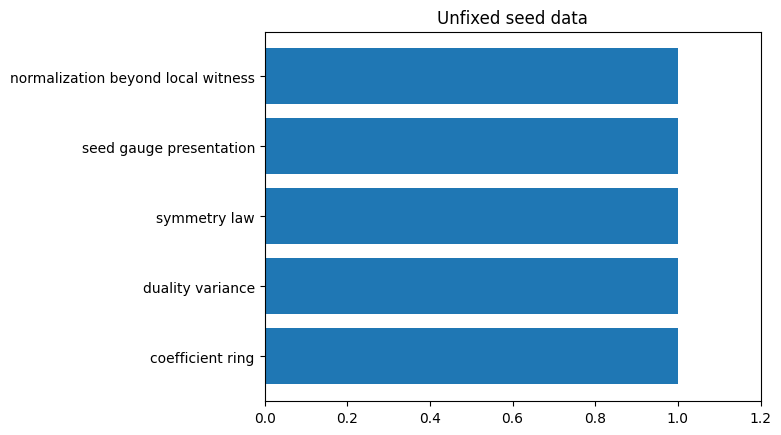

In [5]:
import matplotlib.pyplot as plt
freedom={'coefficient ring':1,'duality variance':1,'symmetry law':1,'seed gauge presentation':1,'normalization beyond local witness':1}
ok=sum(freedom.values())==5
print(('PASS' if ok else 'FAIL')+': seed is not unique at raw presentation level under current authority')
print(freedom)
fig,ax=plt.subplots();ax.barh(list(freedom),list(freedom.values()));ax.set_xlim(0,1.2);ax.set(title='Unfixed seed data');plt.show()

PASS: B local active recurrence a -> a*u/(u+v)
exact ratio= u/(u + v)


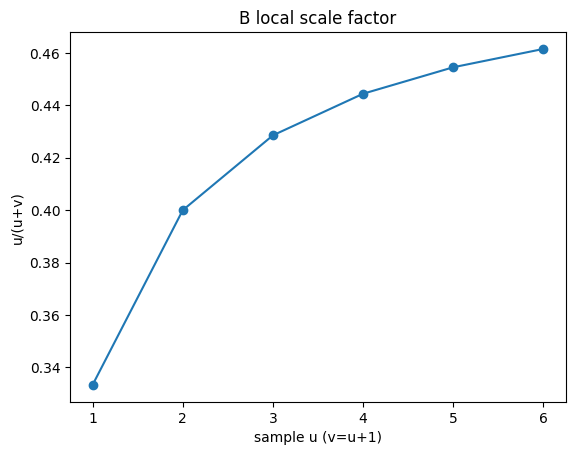

In [6]:
import sympy as sp
import matplotlib.pyplot as plt
u,v=sp.symbols('u v',positive=True)
a=sp.symbols('a')
ratio=sp.simplify((1/(v*(u+v)))/(1/(u*v)))
ok=sp.simplify(ratio-u/(u+v))==0
print(('PASS' if ok else 'FAIL')+': B local active recurrence a -> a*u/(u+v)')
print('exact ratio=',ratio)
vals=[float(sp.N((u/(u+v)).subs({u:n,v:n+1}))) for n in range(1,7)]
fig,ax=plt.subplots();ax.plot(range(1,7),vals,marker='o');ax.set(title='B local scale factor',xlabel='sample u (v=u+1)',ylabel='u/(u+v)');plt.show()

PASS: Q local active recurrence a -> i*a
quarter orbit= [1, I, -1, -I, 1]


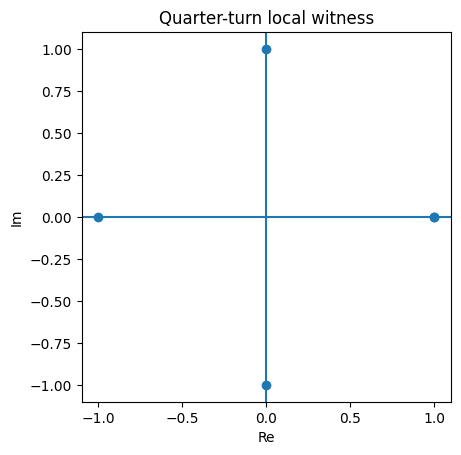

In [7]:
import sympy as sp
import matplotlib.pyplot as plt
a=sp.symbols('a')
seq=[sp.I**n for n in range(5)]
ok=(seq==[1,sp.I,-1,-sp.I,1])
print(('PASS' if ok else 'FAIL')+': Q local active recurrence a -> i*a')
print('quarter orbit=',seq)
fig,ax=plt.subplots();ax.scatter([float(sp.re(z)) for z in seq],[float(sp.im(z)) for z in seq]);ax.axhline(0);ax.axvline(0);ax.set_aspect('equal');ax.set(title='Quarter-turn local witness',xlabel='Re',ylabel='Im');plt.show()

PASS: conditional orthogonal L block retains old block and has zero mixed birth blocks
P_ext=
⎡p₁₁  p₁₂  0⎤
⎢           ⎥
⎢p₂₁  p₂₂  0⎥
⎢           ⎥
⎣ 0    0   s⎦


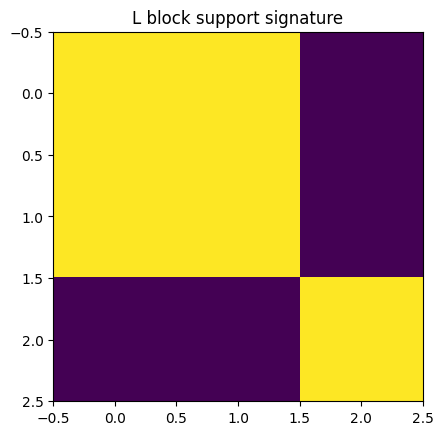

In [8]:
import sympy as sp
import matplotlib.pyplot as plt
p11,p12,p21,p22,s=sp.symbols('p11 p12 p21 p22 s')
P=sp.Matrix([[p11,p12],[p21,p22]])
E=sp.Matrix([[p11,p12,0],[p21,p22,0],[0,0,s]])
ok=(E[:2,:2]==P and E[:2,2]==sp.zeros(2,1) and E[2,:2]==sp.zeros(1,2))
print(('PASS' if ok else 'FAIL')+': conditional orthogonal L block retains old block and has zero mixed birth blocks')
print('P_ext=');sp.pprint(E)
fig,ax=plt.subplots();ax.imshow([[1,1,0],[1,1,0],[0,0,1]],vmin=0,vmax=1);ax.set(title='L block support signature');plt.show()

PASS: first-domain local active axis reaches i/4895
pair= (55, 89) Q count= 5 endpoint= 0.00020429009193054137j


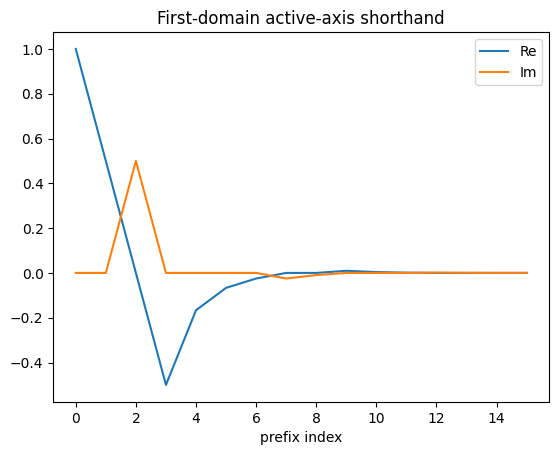

In [9]:
from fractions import Fraction
import matplotlib.pyplot as plt
word='BQQBBBQBQBBQBBL';u=v=1;q=0
vals=[complex(1,0)];labels=['start']
for op in word:
    if op=='B':u,v=v,u+v
    elif op=='Q':q+=1
    elif op=='L':
        labels.append('L');vals.append(complex(0,1/4895));continue
    z=(1j**q)/(u*v);labels.append(op);vals.append(z)
ok=(u,v,q)==(55,89,5) and abs(vals[14]-1j/4895)<1e-18
print(('PASS' if ok else 'FAIL')+': first-domain local active axis reaches i/4895')
print('pair=',(u,v),'Q count=',q,'endpoint=',vals[14])
fig,ax=plt.subplots();ax.plot(range(len(vals)),[z.real for z in vals],label='Re');ax.plot(range(len(vals)),[z.imag for z in vals],label='Im');ax.legend();ax.set(title='First-domain active-axis shorthand',xlabel='prefix index');plt.show()

PASS: full pairing is underdetermined after L even when local diagonals agree
model 0= Matrix([[a0, 0], [0, a1]]) model chi= Matrix([[a0, chi], [0, a1]])


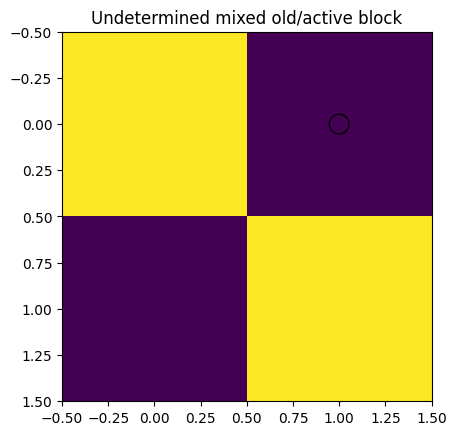

In [10]:
import sympy as sp
import matplotlib.pyplot as plt
a0,a1,chi=sp.symbols('a0 a1 chi')
P0=sp.Matrix([[a0,0],[0,a1]])
P1=sp.Matrix([[a0,chi],[0,a1]])
same_old=P0[0,0]==P1[0,0]
same_active=P0[1,1]==P1[1,1]
different=P0!=P1
ok=same_old and same_active and different
print(('PASS' if ok else 'FAIL')+': full pairing is underdetermined after L even when local diagonals agree')
print('model 0=',P0,'model chi=',P1)
fig,ax=plt.subplots();ax.imshow([[1,0],[0,1]],vmin=0,vmax=1);ax.scatter([1],[0],s=200,facecolors='none',edgecolors='black');ax.set(title='Undetermined mixed old/active block');plt.show()

PASS: current signatures admit both count-only and order-sensitive candidate laws
formal controls only; not both canonical lawful prefixes: {'BQ': 0, 'QB': 1}


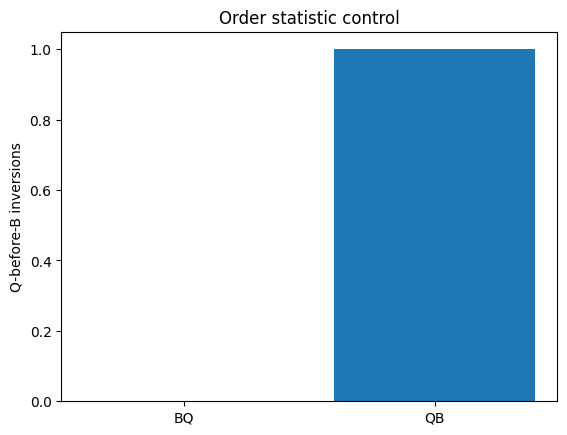

In [11]:
import matplotlib.pyplot as plt
def inversion_word(w): return sum(1 for i in range(len(w)) for j in range(i+1,len(w)) if w[i]=='Q' and w[j]=='B')
formal_words=['BQ','QB']
count_only=[0,0]
order_sensitive=[inversion_word(w) for w in formal_words]
ok=(count_only[0]==count_only[1] and order_sensitive[0]!=order_sensitive[1])
print(('PASS' if ok else 'FAIL')+': current signatures admit both count-only and order-sensitive candidate laws')
print('formal controls only; not both canonical lawful prefixes:',dict(zip(formal_words,order_sensitive)))
fig,ax=plt.subplots();ax.bar(formal_words,order_sensitive);ax.set(title='Order statistic control',ylabel='Q-before-B inversions');plt.show()

PASS: one P generates two restrictions and two directed mixed blocks
{'Omega+': p11, 'Omega-': p22, 'T+->-': p21, 'T-->+': p12}


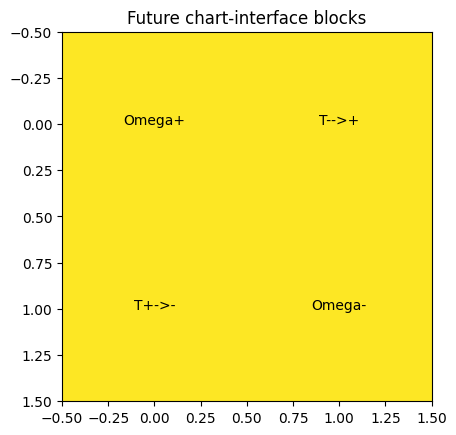

In [12]:
import sympy as sp
import matplotlib.pyplot as plt
p11,p12,p21,p22=sp.symbols('p11 p12 p21 p22')
P=sp.Matrix([[p11,p12],[p21,p22]])
eplus=sp.Matrix([[1],[0]]);eminus=sp.Matrix([[0],[1]])
blocks={'Omega+':(eplus.T*P*eplus)[0],'Omega-':(eminus.T*P*eminus)[0],'T+->-':(eminus.T*P*eplus)[0],'T-->+':(eplus.T*P*eminus)[0]}
ok=list(blocks.values())==[p11,p22,p21,p12]
print(('PASS' if ok else 'FAIL')+': one P generates two restrictions and two directed mixed blocks')
print(blocks)
fig,ax=plt.subplots();ax.imshow([[1,1],[1,1]],vmin=0,vmax=1);ax.text(0,0,'Omega+',ha='center');ax.text(1,1,'Omega-',ha='center');ax.text(0,1,'T+->-',ha='center');ax.text(1,0,'T-->+',ha='center');ax.set(title='Future chart-interface blocks');plt.show()

PASS: higher-order descriptive L status follows from explicit missing premises
status= NOT_YET_DERIVED
{'pairing values closed': False, 'lawful comparison family': False, 'old-description fibers defined': False, 'new-axis coordinate defined': False}


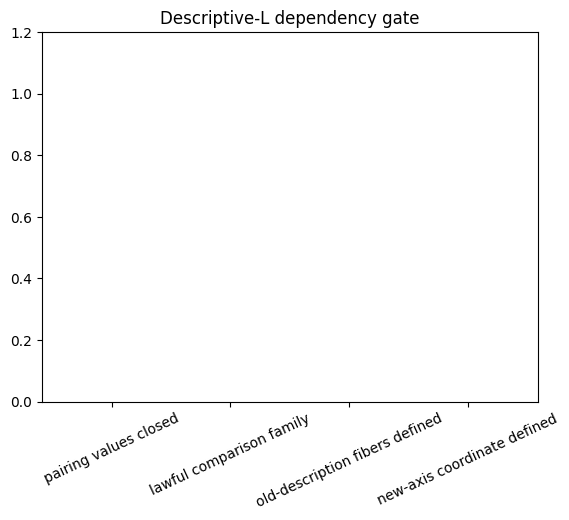

In [13]:
import matplotlib.pyplot as plt
premises={'pairing values closed':False,'lawful comparison family':False,'old-description fibers defined':False,'new-axis coordinate defined':False}
status='NOT_YET_DERIVED' if not all(premises.values()) else 'PROVED'
ok=(status=='NOT_YET_DERIVED')
print(('PASS' if ok else 'FAIL')+': higher-order descriptive L status follows from explicit missing premises')
print('status=',status);print(premises)
fig,ax=plt.subplots();ax.bar(list(premises),[int(v) for v in premises.values()]);ax.set_ylim(0,1.2);ax.tick_params(axis='x',rotation=25);ax.set(title='Descriptive-L dependency gate');plt.show()

PASS: negative control with nonzero old/new birth block is rejected
old block preserved= True orthogonality= False


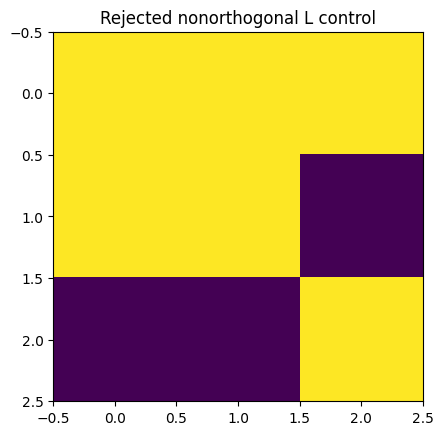

In [14]:
import sympy as sp
import matplotlib.pyplot as plt
P=sp.Matrix([[2,3],[5,7]])
bad=sp.Matrix([[2,3,1],[5,7,0],[0,0,11]])
old_ok=(bad[:2,:2]==P)
orthogonal=(bad[:2,2]==sp.zeros(2,1) and bad[2,:2]==sp.zeros(1,2))
rejected=old_ok and not orthogonal
print(('PASS' if rejected else 'FAIL')+': negative control with nonzero old/new birth block is rejected')
print('old block preserved=',old_ok,'orthogonality=',orthogonal)
fig,ax=plt.subplots();ax.imshow([[1,1,1],[1,1,0],[0,0,1]],vmin=0,vmax=1);ax.set(title='Rejected nonorthogonal L control');plt.show()